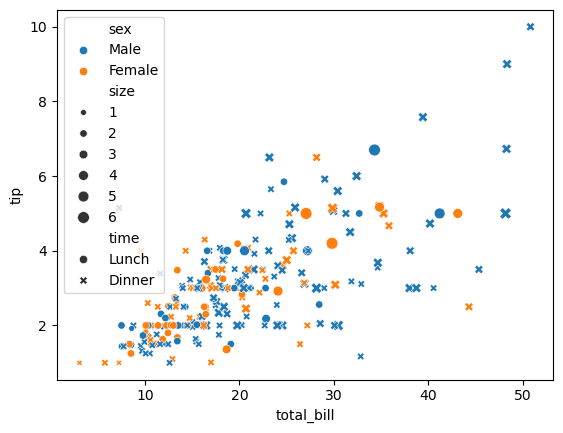

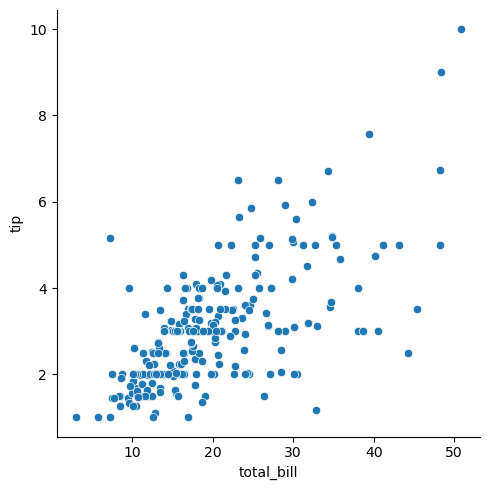

In [9]:
###RELATIONAL PLOT : SCATTER
# scatterplot -> axes level (rect)
# relplot -> figure level (squa) legend outside
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
tips=sns.load_dataset('tips')
sns.scatterplot(data=tips,y='tip',x='total_bill',hue='sex',style='time',size='size')
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter')

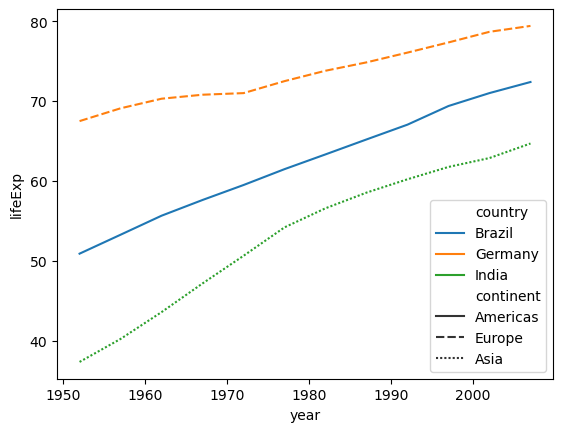

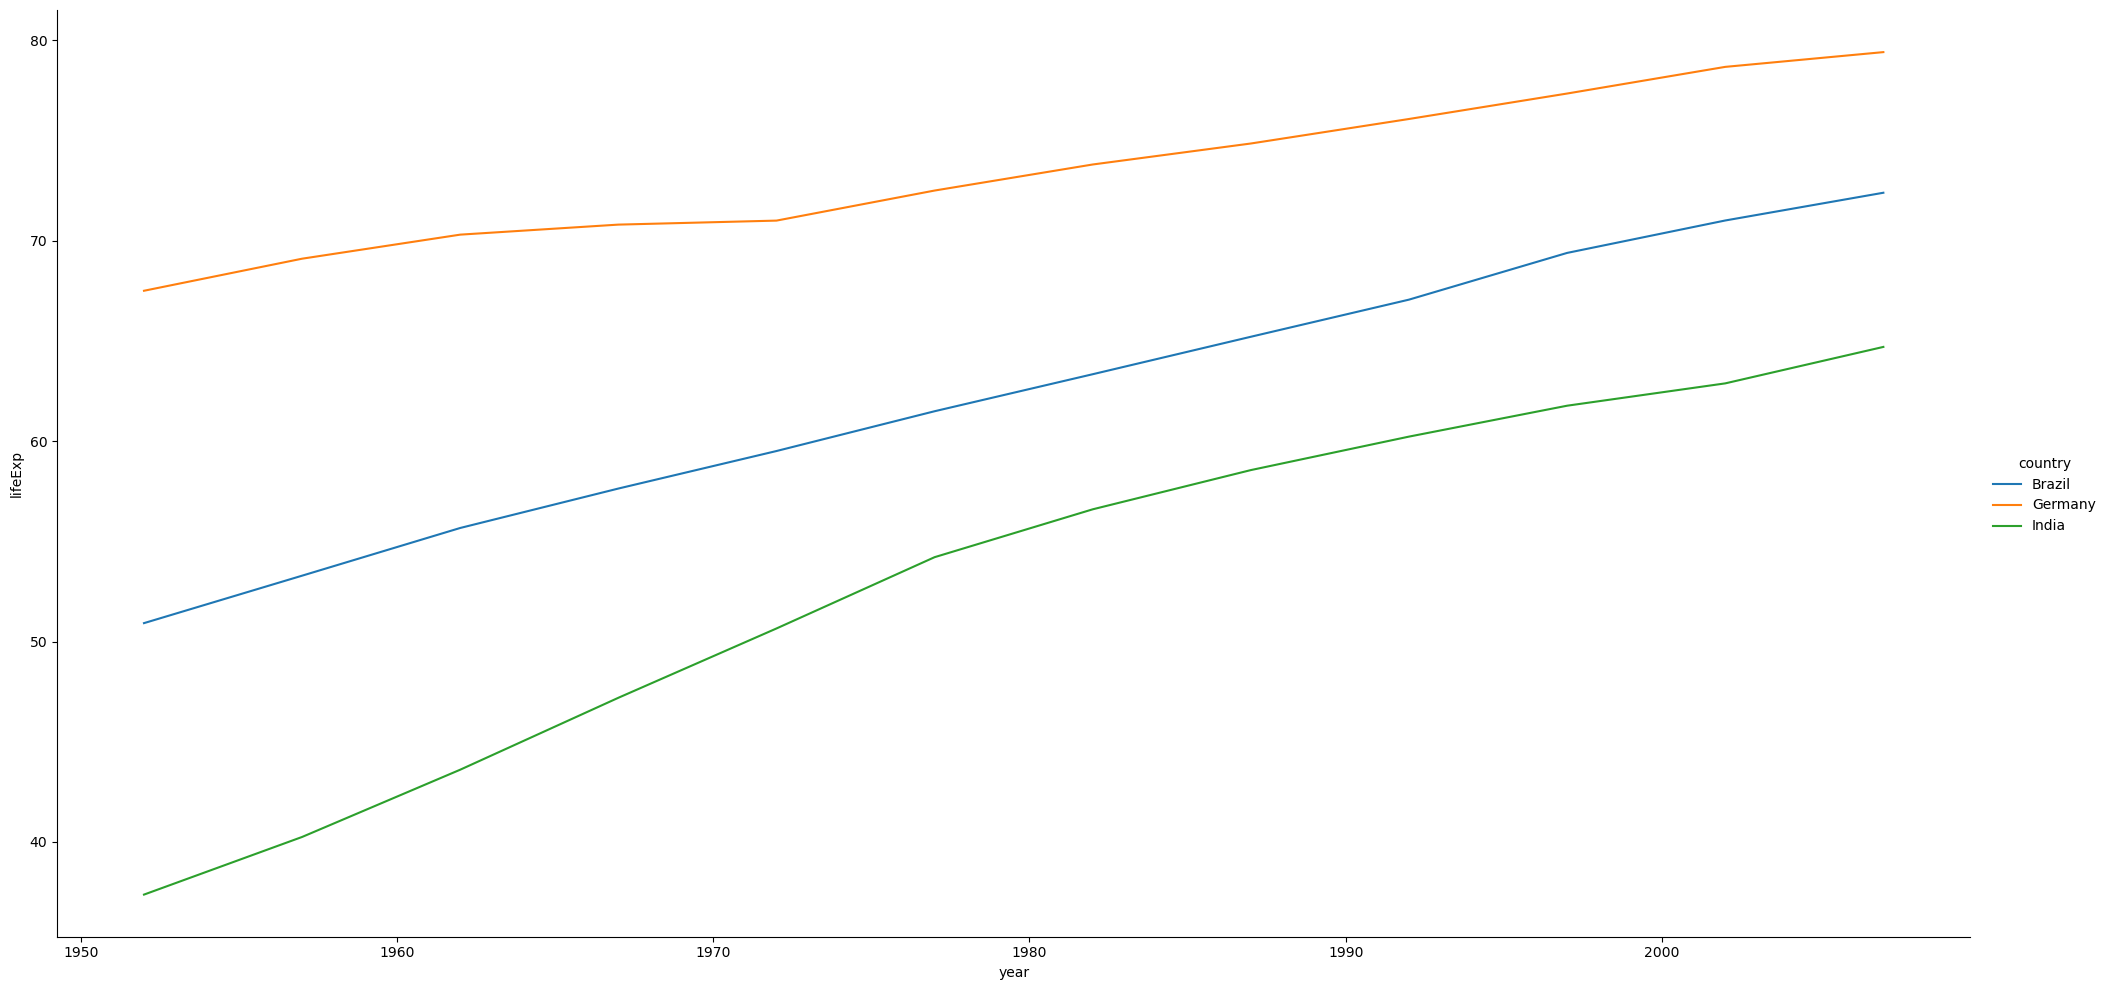

In [57]:
###RELATIONAL PLOT : LINE
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
gap=px.data.gapminder()
df=gap[gap['country'].isin(['India','Brazil','Germany'])]
sns.lineplot(data=df,x='year',y='lifeExp',hue='country',style='continent')
#height ans aspect
sns.relplot(data=df,x='year',y='lifeExp',kind='line',hue='country',height=10,aspect=2)

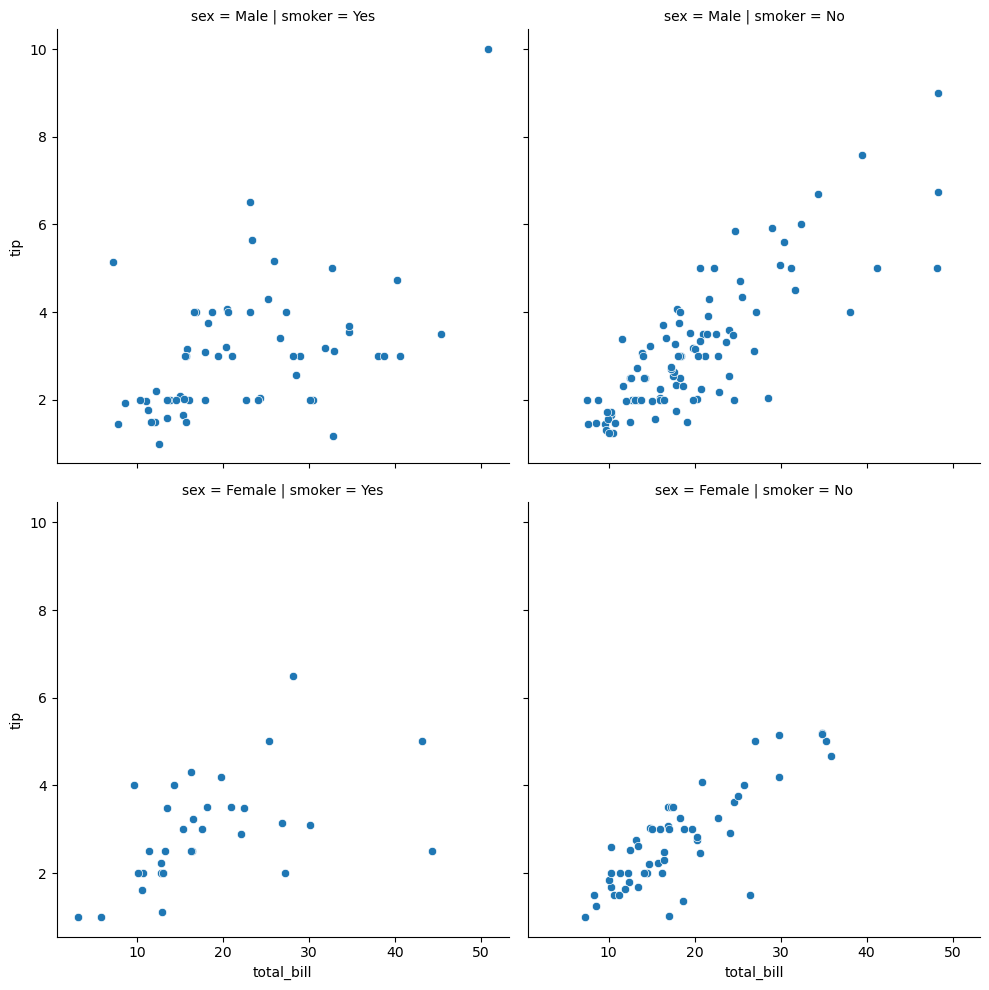

In [21]:
###RELATIONAL PLOT : Facet plot -> only works with figure level function
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='smoker',row='sex')

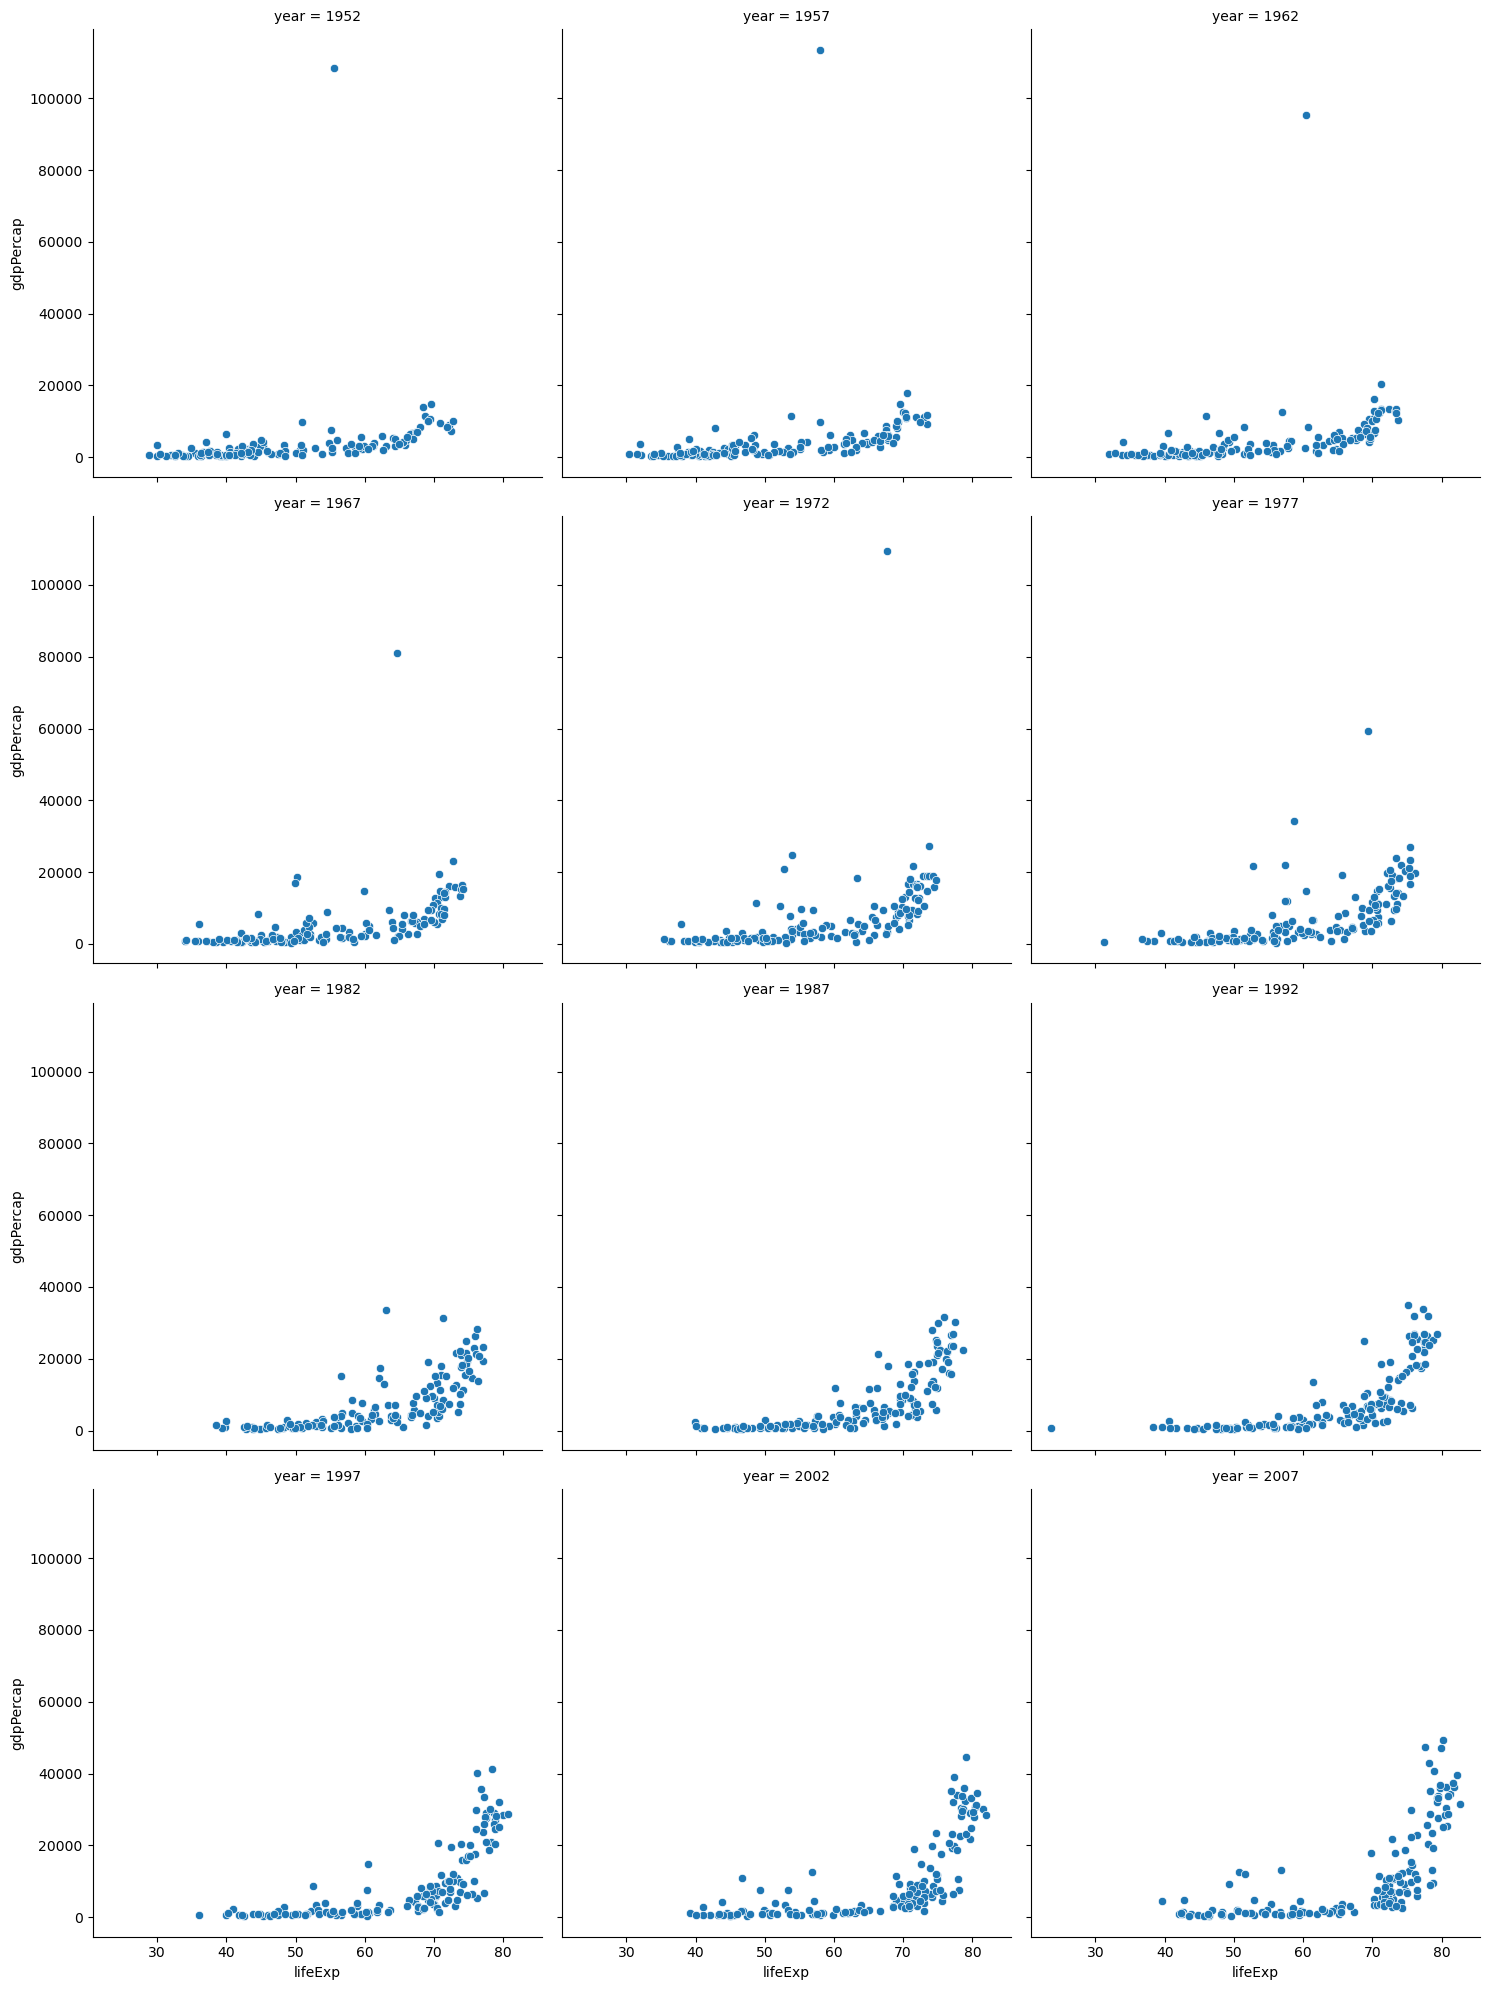

In [24]:
# col_wrap
sns.relplot(data=gap,x='lifeExp',y='gdpPercap',kind='scatter',col='year',col_wrap=3)

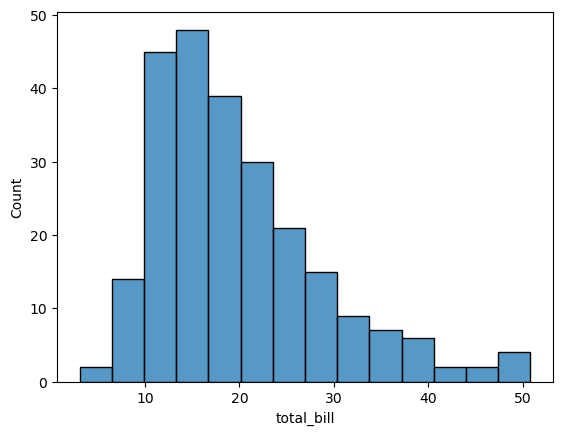

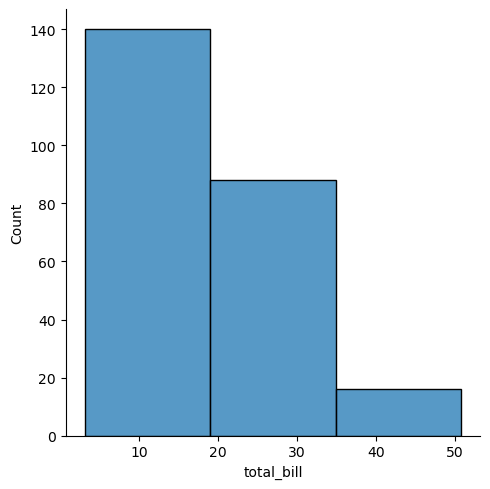

In [29]:
###DISTRIBUTION PLOTS
#figure level -> displot
# axes level -> histplot, kdeplot, rugplot
#plotting histogram
#can use bins
sns.histplot(data=tips,x='total_bill')
sns.displot(data=tips,x='total_bill',kind='hist',bins=3)


<Axes: xlabel='day', ylabel='Count'>

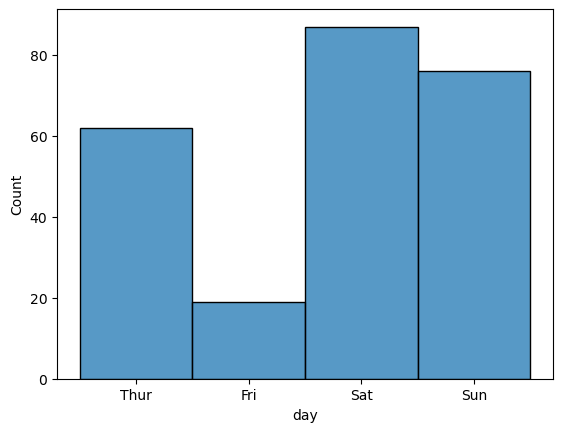

In [30]:
#hist can act as count plot for categorical data
sns.histplot(data=tips,x='day')

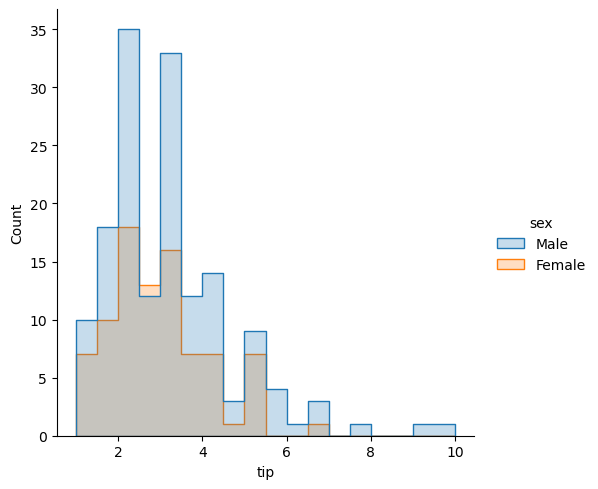

In [32]:
#hue parameter + element for clean
sns.displot(data=tips,x='tip',kind='hist',hue='sex',element='step')


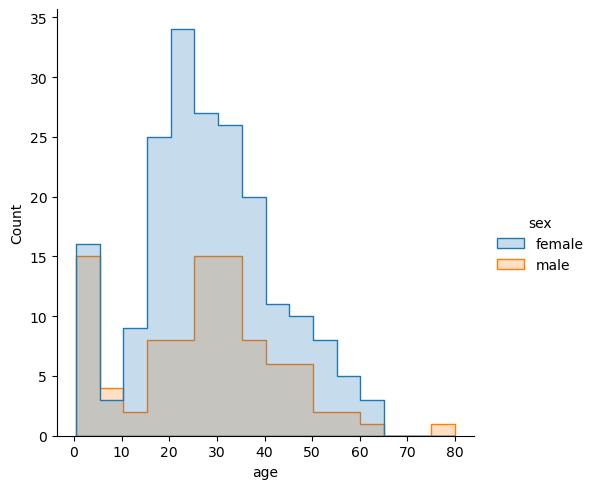

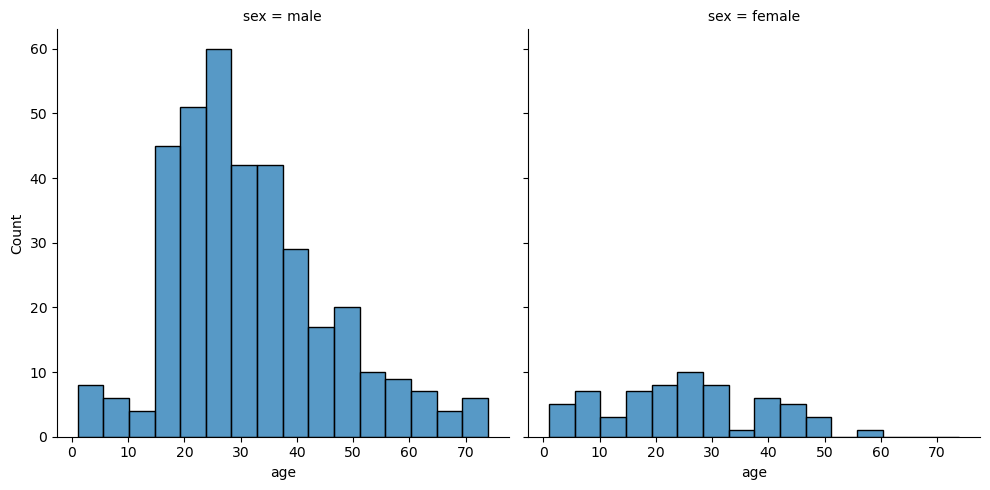

In [40]:
#titanic dataset
titanic=sns.load_dataset('titanic')
df1=titanic[titanic['survived']==0]
df=titanic[titanic['survived']==1]
sns.displot(data=df,kind='hist',x='age',hue='sex',element='step')
#using facet 
sns.displot(data=df1,kind='hist',x='age',col='sex')

<Axes: xlabel='total_bill', ylabel='Density'>

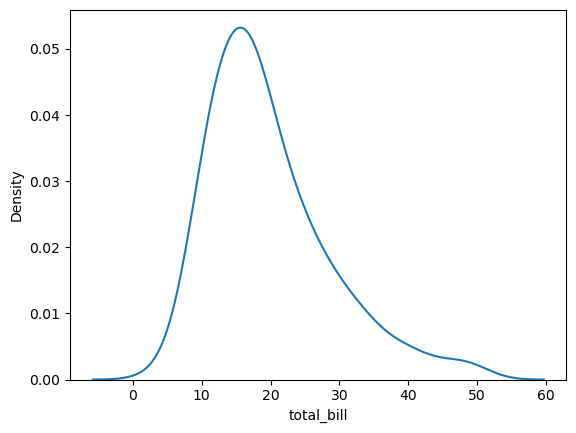

In [41]:
# kdeplot
sns.kdeplot(data=tips,x='total_bill')

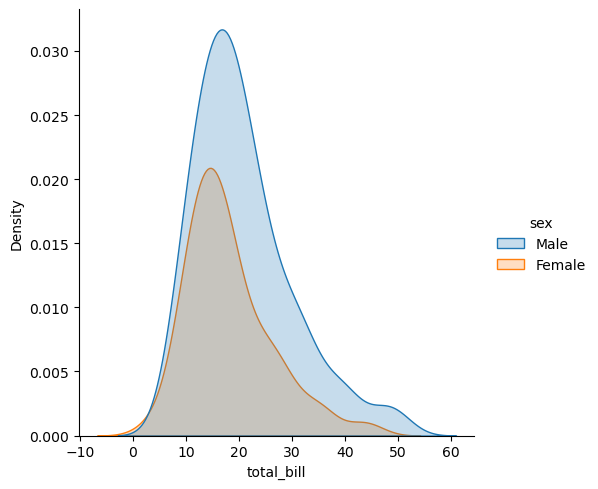

In [44]:
#kde using displot + using fill
sns.displot(kind='kde',data=tips,x='total_bill',hue='sex',fill=True)

<Axes: xlabel='total_bill', ylabel='Density'>

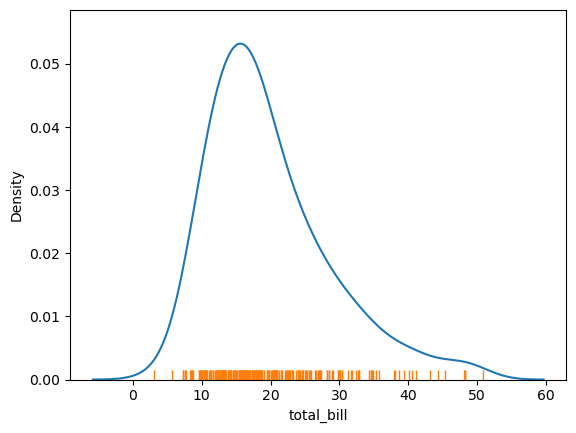

In [45]:
# rugplot
#plot marginal distribution by ticks
sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

<Axes: xlabel='total_bill', ylabel='tip'>

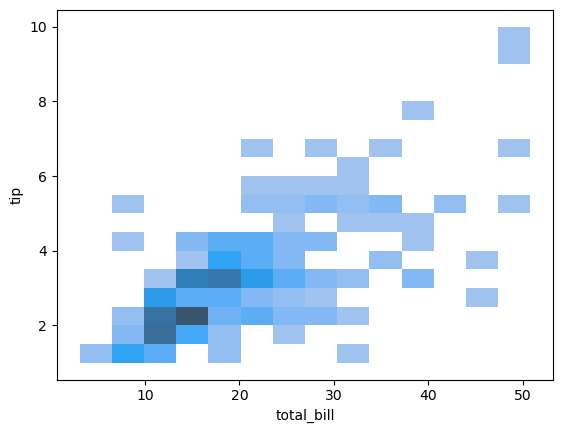

In [46]:
#bivariate histogram
sns.histplot(data=tips,x='total_bill',y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

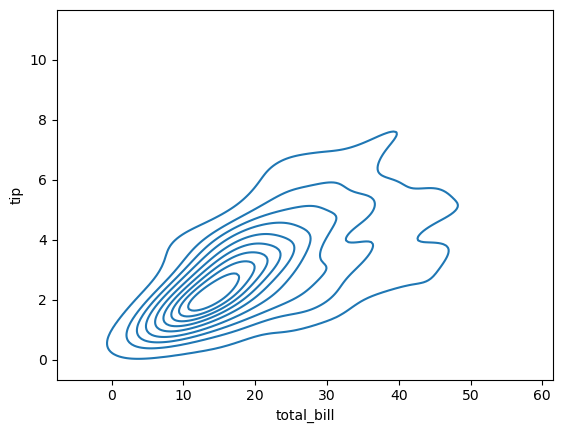

In [47]:
#bivariate kdeplot -> 2d gaussian function used to smooth
sns.kdeplot(data=tips,x='total_bill',y='tip')

<Axes: xlabel='year', ylabel='country'>

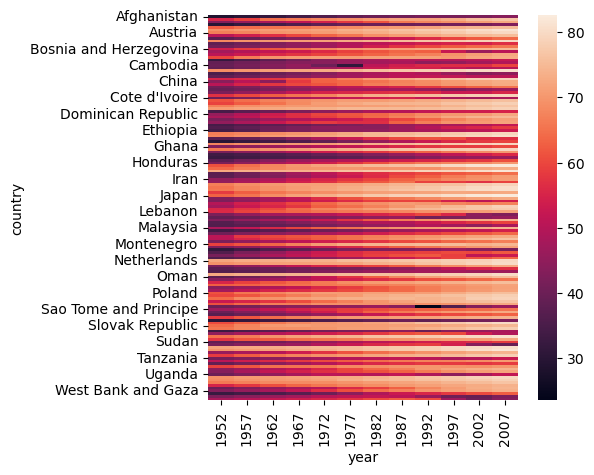

In [49]:
###MATRIX PLOT
# heatmap -> plots a rectangular data as a color-encoded matrix
temp=gap.pivot(index='country',columns='year',values='lifeExp')
plt.figure(figsize=(5,5))
sns.heatmap(temp)

<Axes: xlabel='year', ylabel='country'>

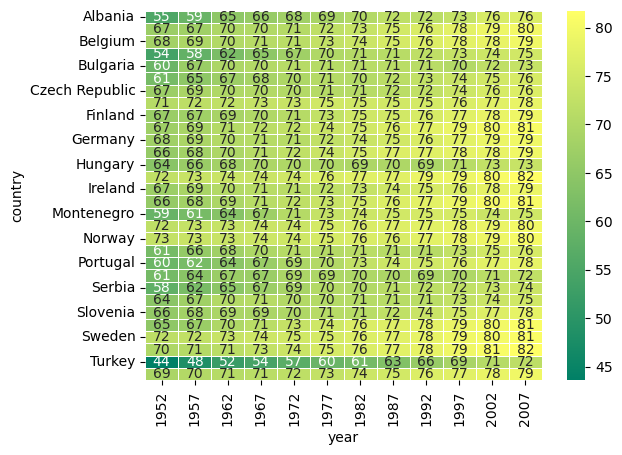

In [52]:
#annot keyword to show values too
#linewidth for gap
# cmap for color change
temp=gap[gap['continent']=='Europe'].pivot(index='country',columns='year',values='lifeExp')
sns.heatmap(temp,cmap='summer',linewidth=0.5,annot=True)

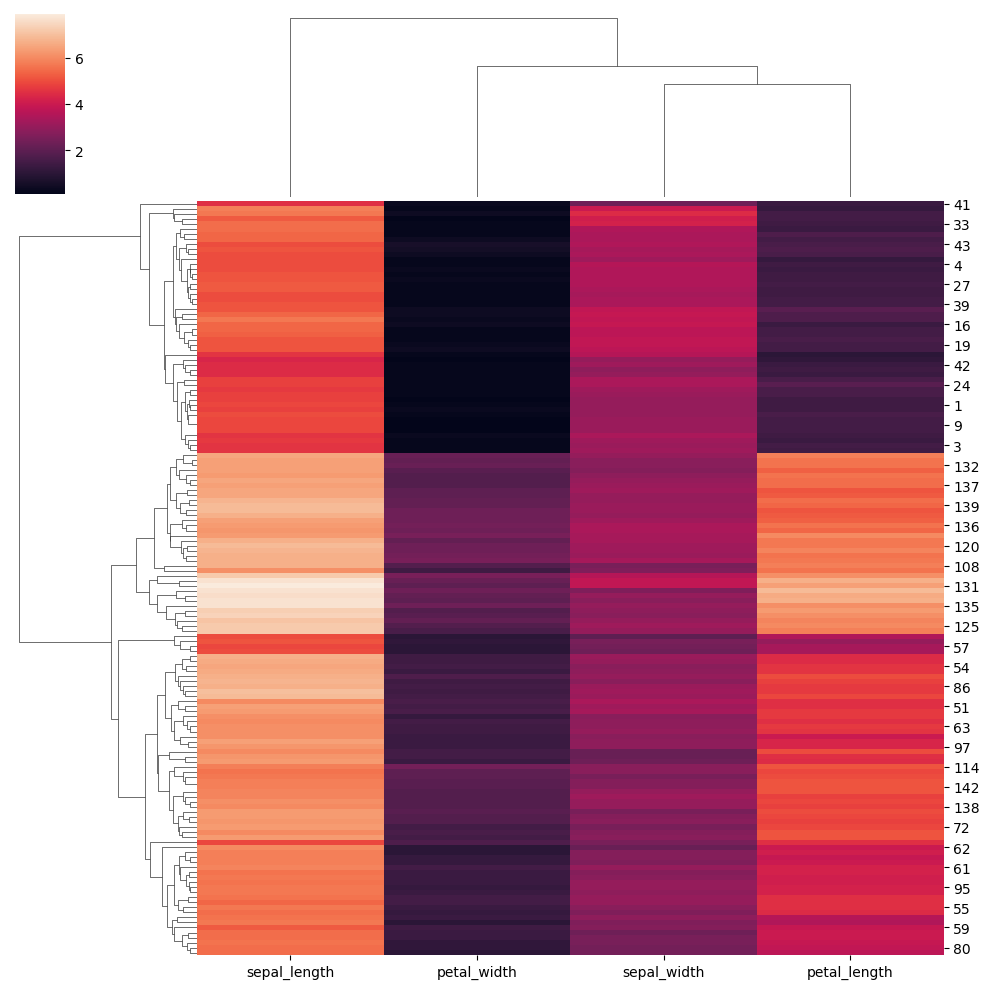

In [56]:
#cluster map
# it requires scipy
df=px.data.iris()
sns.clustermap(df.iloc[:,[0,1,2,3]])

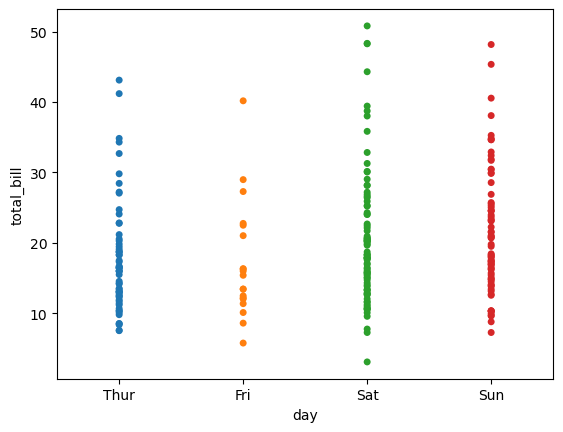

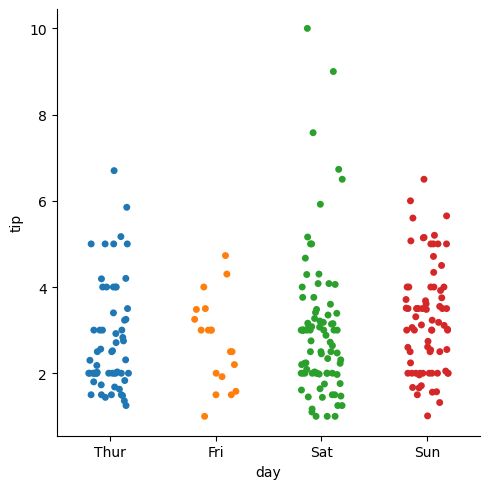

In [66]:
### CATEGORICAL PLOT
# 1. categorical scatter plot -> stripplot,swarmplot
iris=sns.load_dataset('iris')
#jitter adds noise
sns.stripplot(data=tips,x='day',y='total_bill',hue='day',jitter=False)
#figure level -> catplot
sns.catplot(data=tips,x='day',y='tip',kind='strip',hue='day',jitter=0.2)

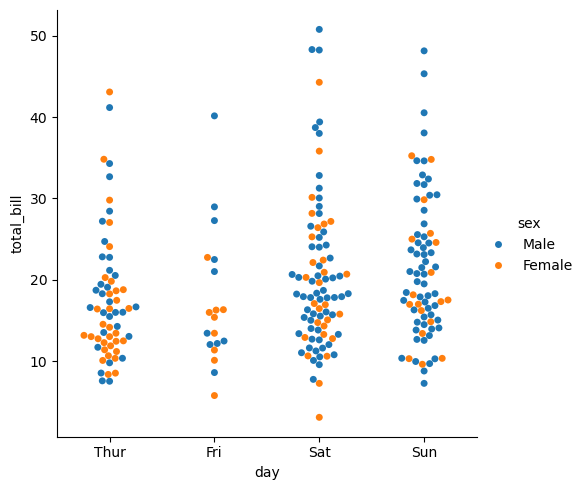

In [71]:
# swarm plot -> scatter only but runs an algorithm to show distribution
sns.catplot(data=tips,kind='swarm',x='day',y='total_bill',hue='sex')

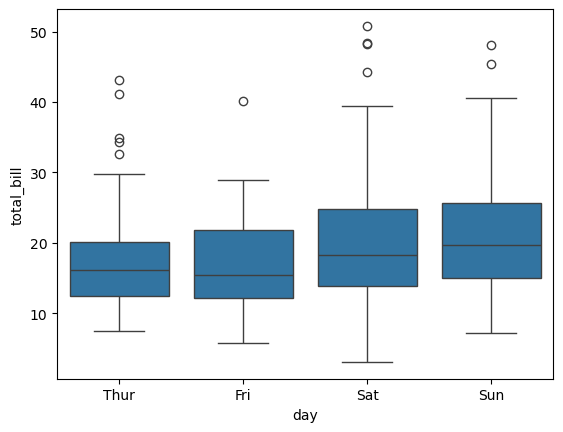

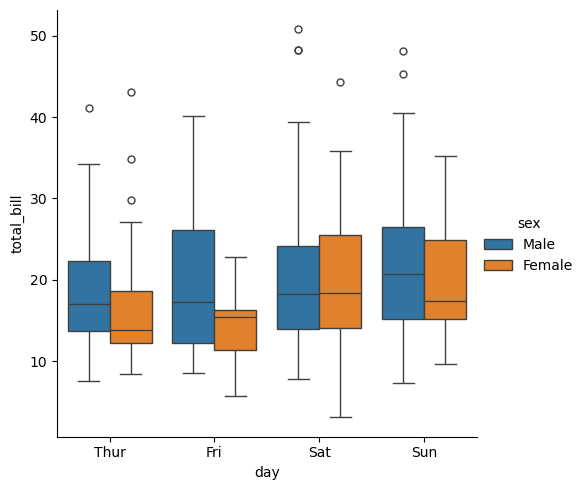

In [75]:
#2) Categorical distribution plot -> boxplot, violinplot
sns.boxplot(data=tips,y='total_bill',x='day')
sns.catplot(data=tips,y='total_bill',x='day',kind='box',hue='sex')

<Axes: ylabel='total_bill'>

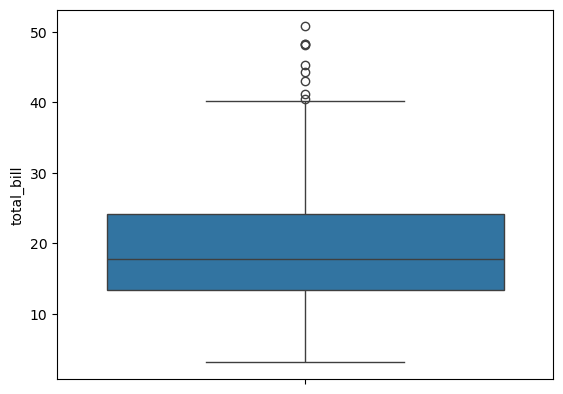

In [76]:
#1d box
sns.boxplot(data=tips,y='total_bill')

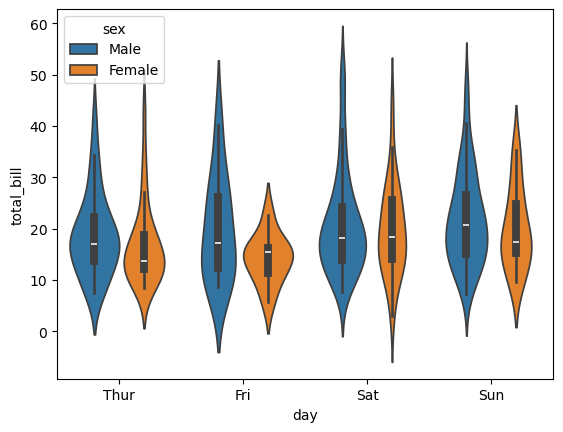

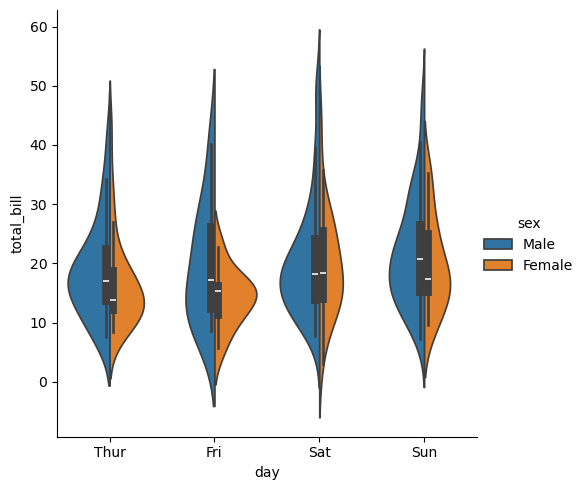

In [79]:
#violin plot -> combination of box and kde
sns.violinplot(data=tips,x='day',y='total_bill',hue='sex')
#can use split if not wanted side by side
sns.catplot(data=tips,x='day',y='total_bill',hue='sex',kind='violin',split=True)


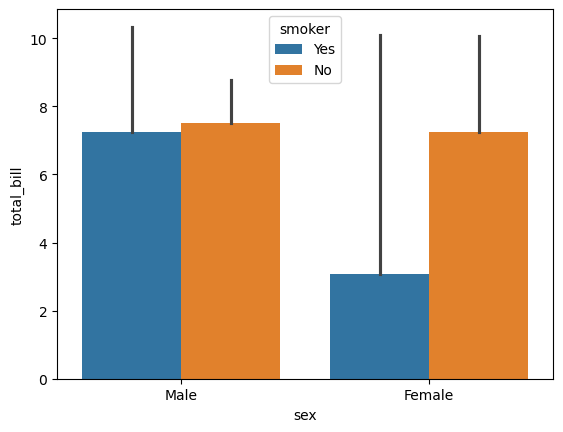

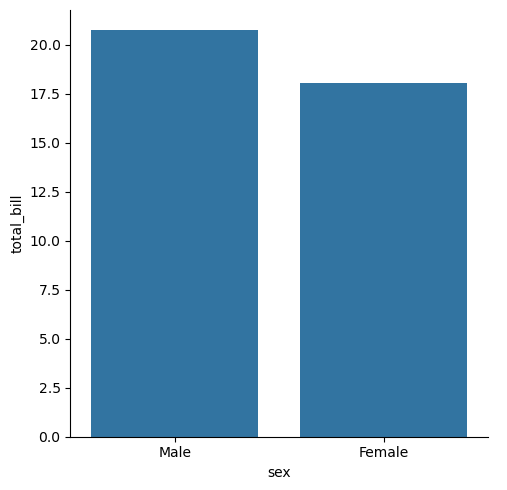

In [85]:
#categorical estimate plots for central tendency -> bar, point, count
# barplot -> the upper lines are error bars uses bootstrapping for confidence interval
# remove error bar -> errorbar=None
#default is mean but can customize using estimator
#orient='h' for horizontal bar
import numpy as np
sns.barplot(data=tips,x='sex',y='total_bill',hue='smoker',estimator=np.min)
sns.catplot(data=tips,x='sex',y='total_bill',kind='bar',errorbar=None)

<Axes: xlabel='sex', ylabel='total_bill'>

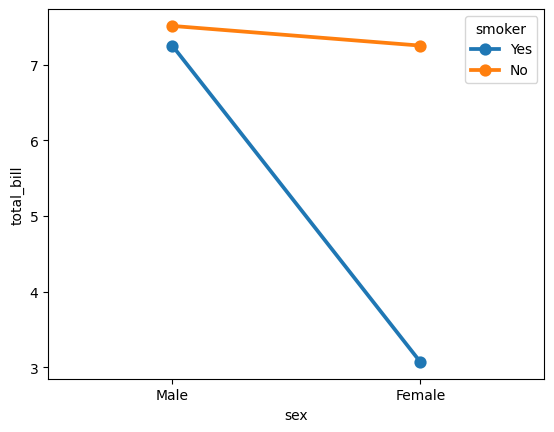

In [89]:
#point plot
sns.pointplot(data=tips,x='sex',y='total_bill',hue='smoker',estimator=np.min,errorbar=None)

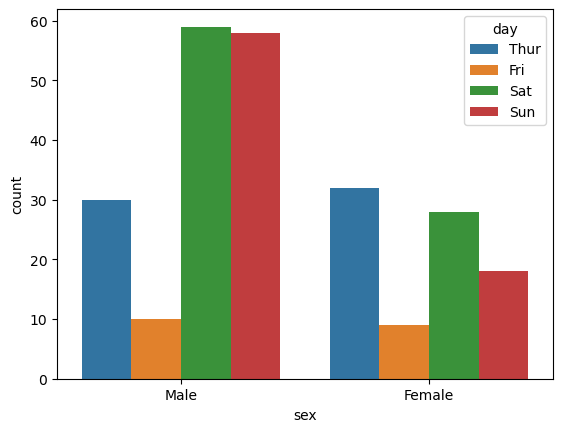

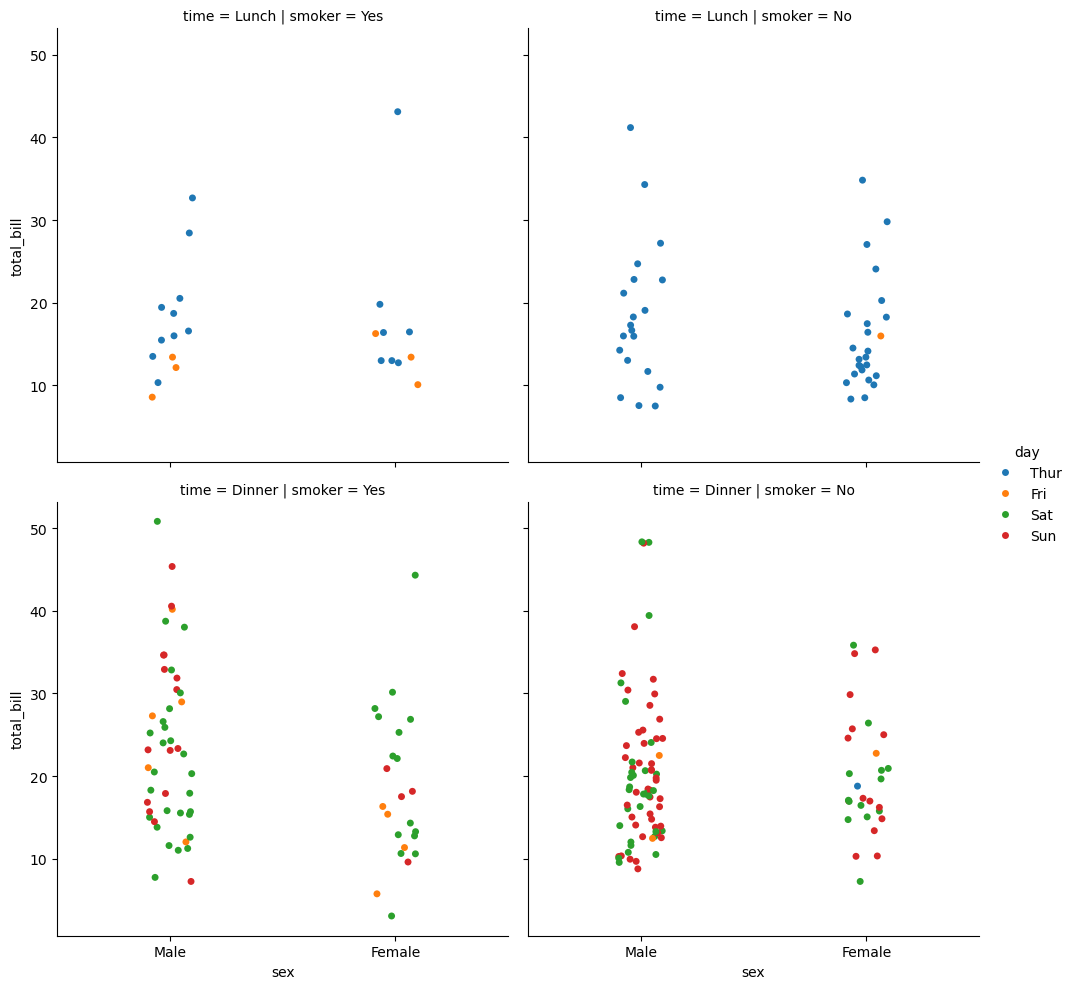

In [97]:
#countplot
sns.countplot(data=tips,x='sex',hue='day')
#faceting
sns.catplot(data=tips,y='total_bill',x='sex',kind='strip',col='smoker',row='time',hue='day')

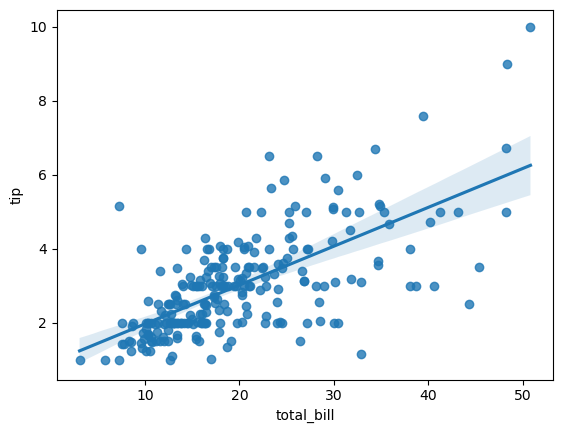

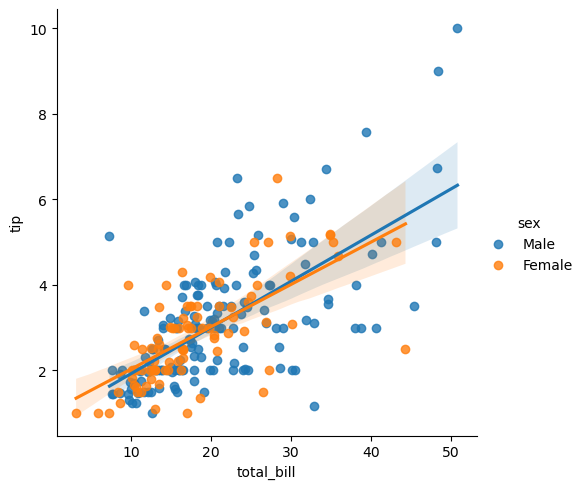

In [99]:
### REGPLOT -> regression plot : regplot, lmplot_. lmplot is figure level
#hue not available in regplot
sns.regplot(data=tips,x='total_bill',y='tip')
sns.lmplot(data=tips,x='total_bill',y='tip',hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

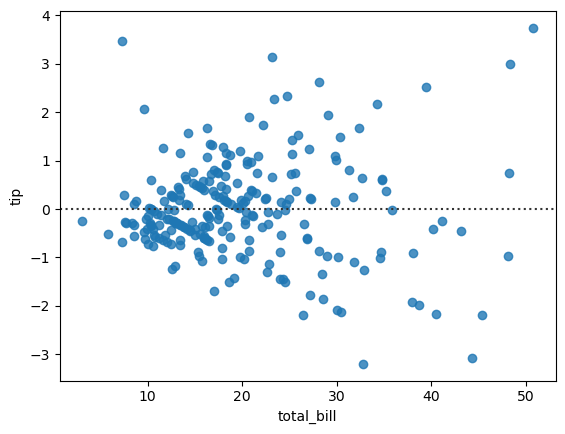

In [100]:
#residplot -> error in linear regression
sns.residplot(data=tips,x='total_bill',y='tip')

C:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


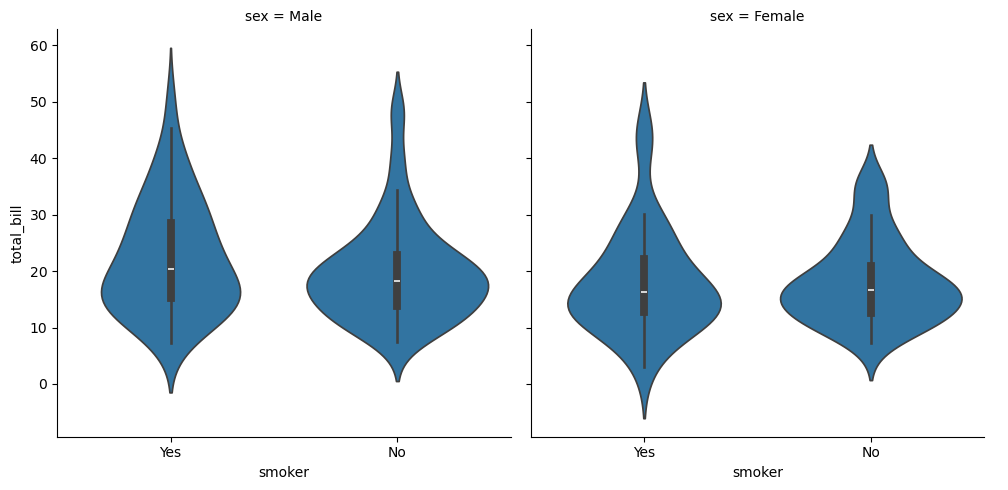

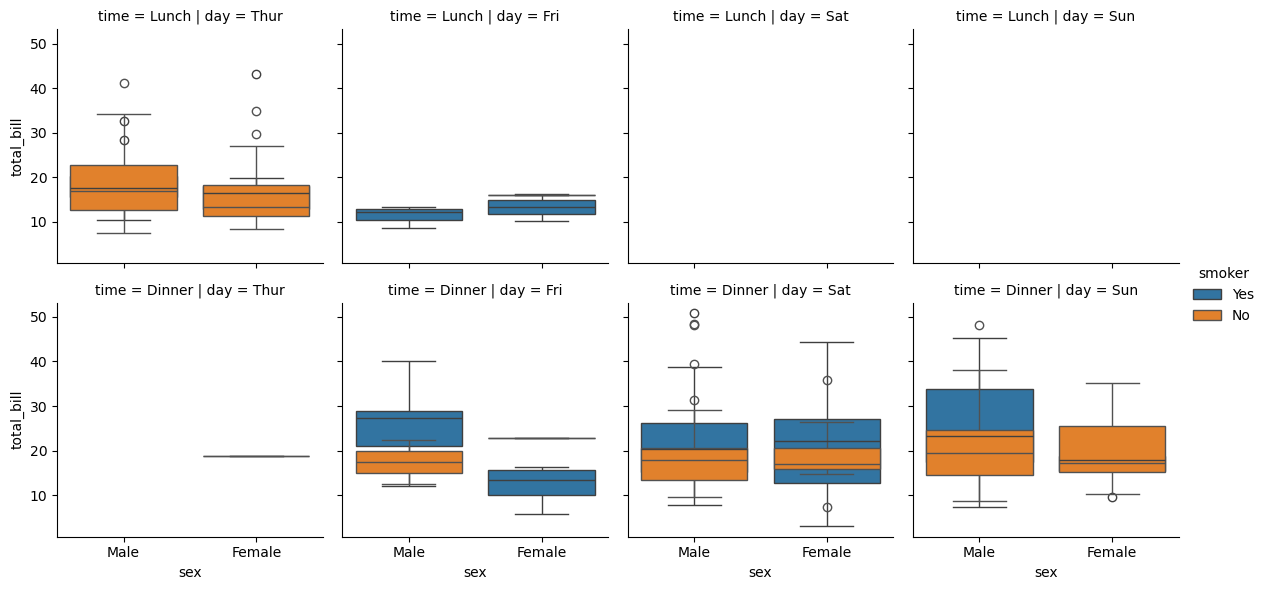

In [106]:
###MULTIPLOT OR MULTIGRID PLOT
# FacetGrid _. a second way for facet plotting
sns.catplot(kind='violin',data=tips,x='smoker',y='total_bill',col='sex')
g=sns.FacetGrid(data=tips,col='day',row='time',hue='smoker')
g.map(sns.boxplot,'sex','total_bill')
g.add_legend()

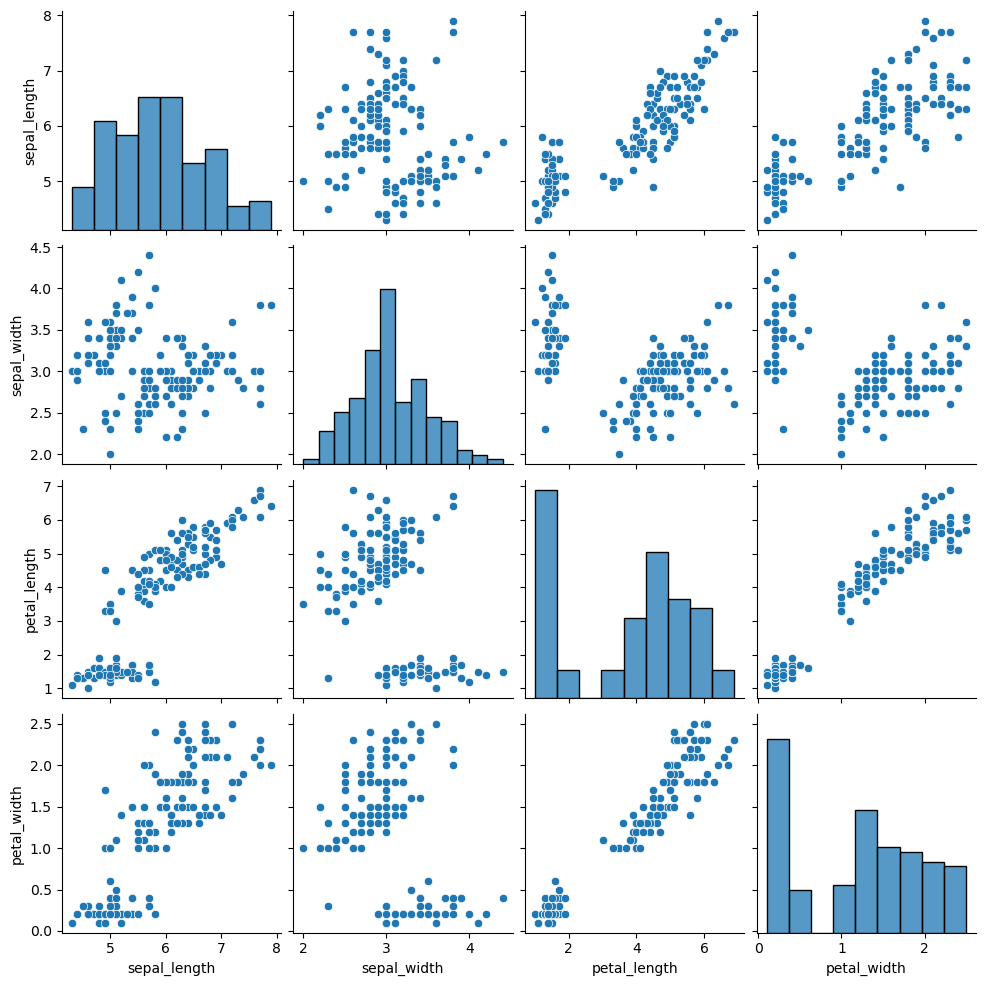

In [107]:
#pair plot -> scatter plot bw every numerical pair and for same col, hist
sns.pairplot(iris)

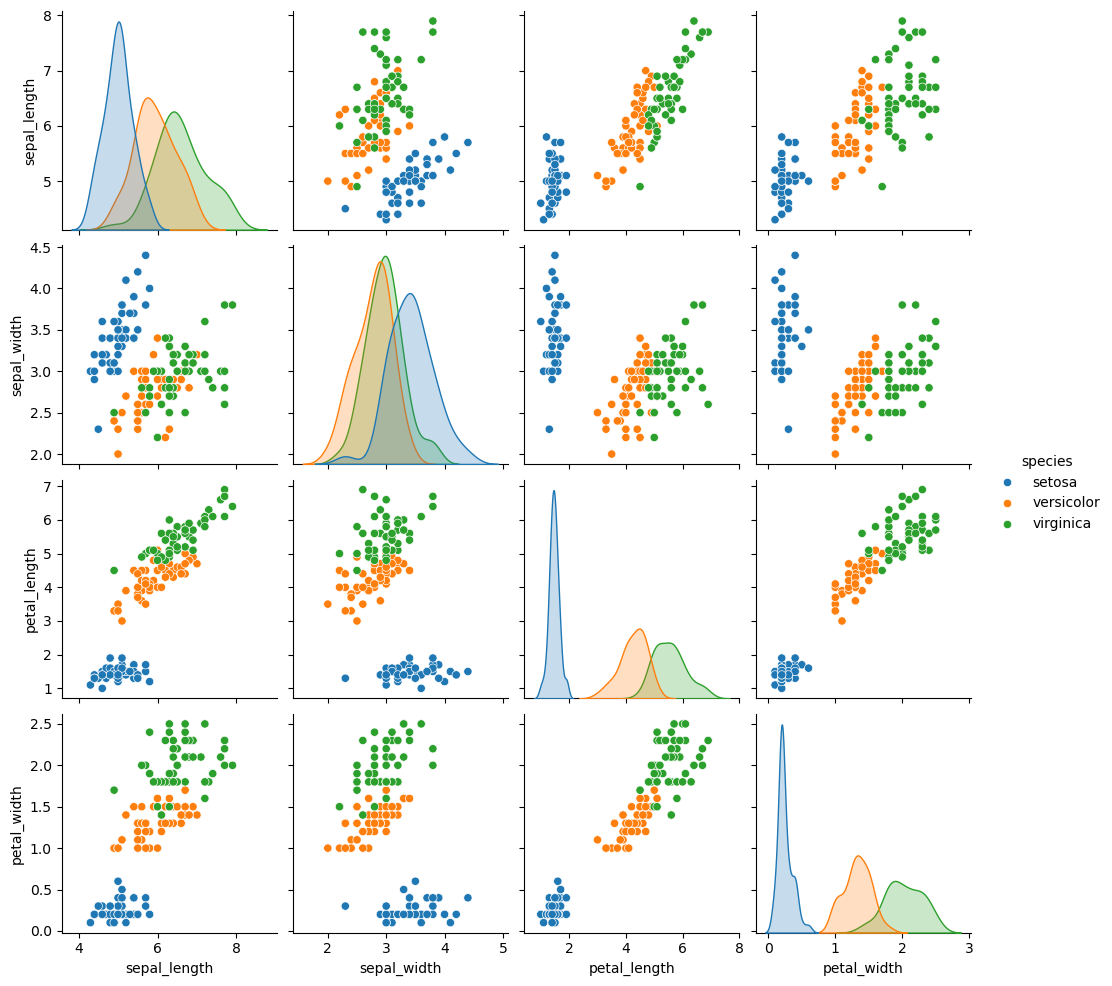

In [108]:
#using hue in pairplot
sns.pairplot(iris,hue='species')

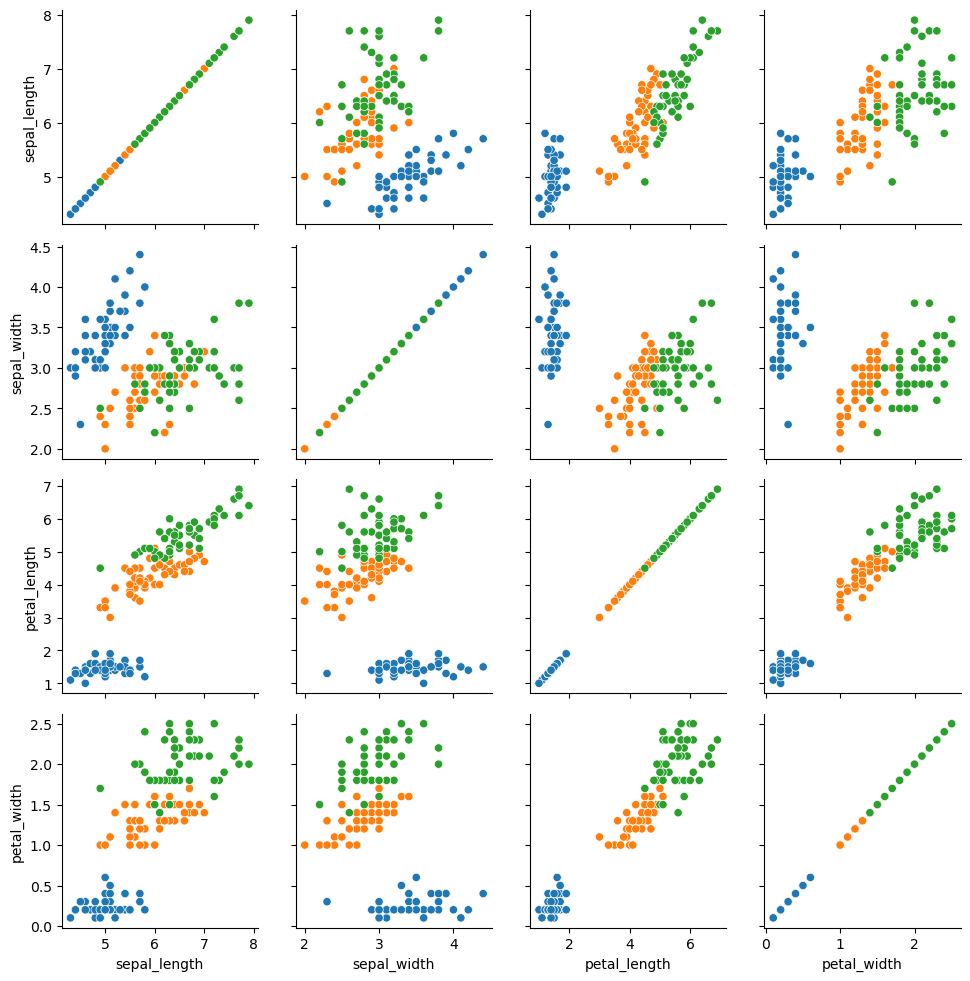

In [112]:
#Pair grid
g=sns.PairGrid(data=iris,hue='species')
g.map(sns.scatterplot)

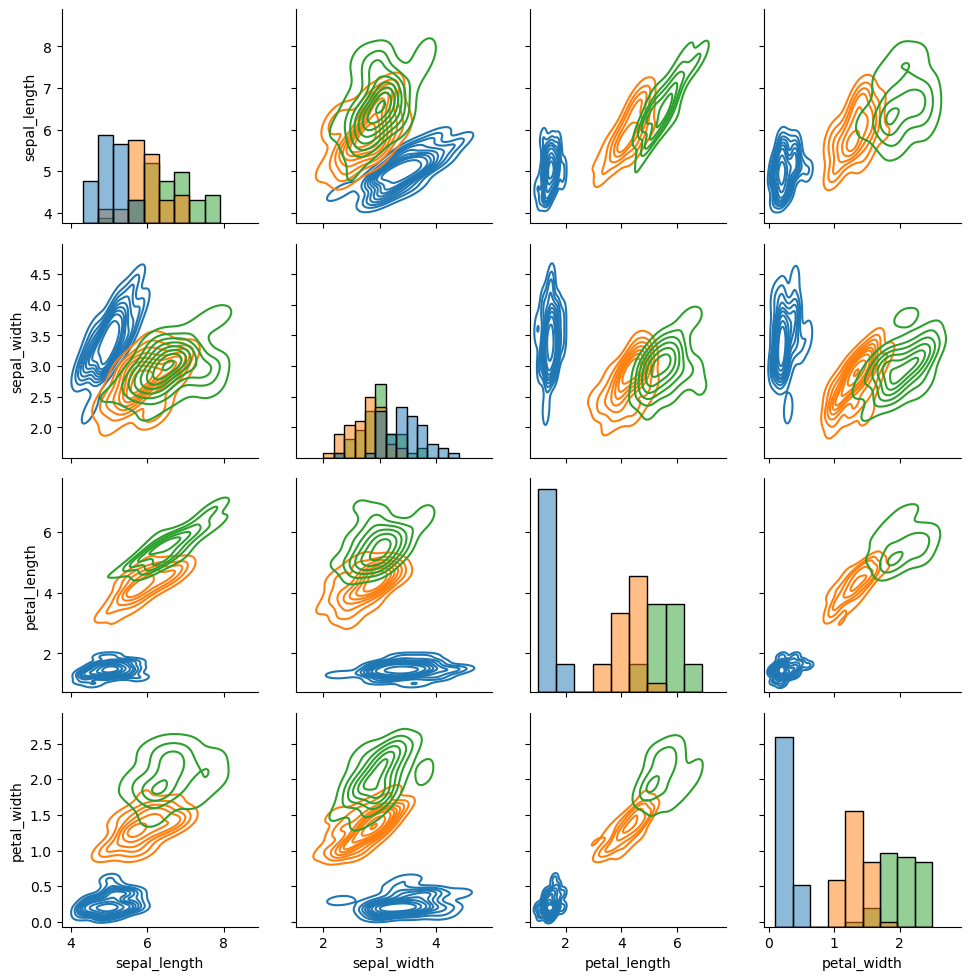

In [114]:
# using pairgrid plot diagnol and non diagonal differently: map_diag and map_offdiag 
#also, we can plot upper and lower triagular plots differently
# using map_upper and map_lower.
# also if we want to use only specific columns, we can use vars=[] in the pairgrid
g=sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.histplot)
g.map_offdiag(sns.kdeplot)

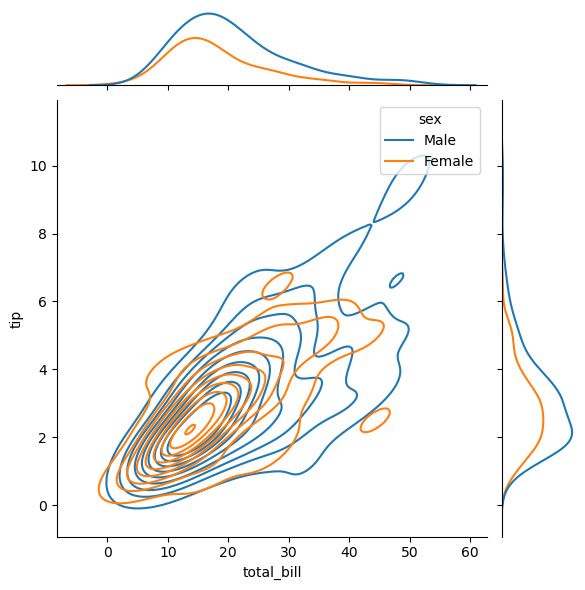

In [115]:
#jointplot and jointgrid
#jointplot -> default kind='scatter'
sns.jointplot(data=tips,x='total_bill',y='tip',kind='kde',hue='sex')

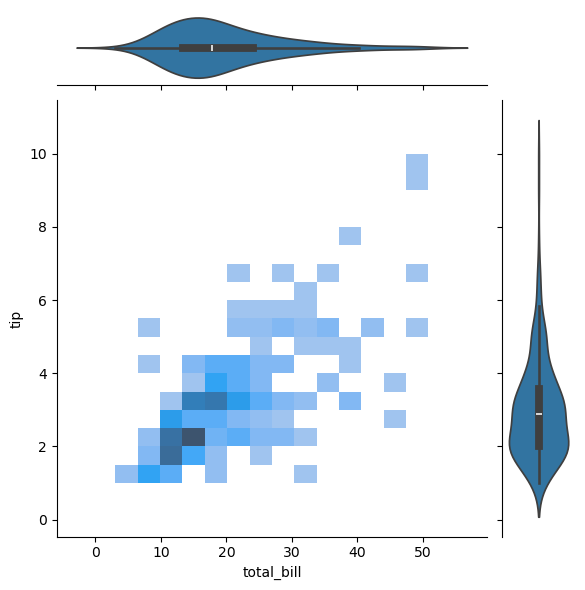

In [116]:
#using joint grid -> benifit to change individual plots
g=sns.JointGrid(data=tips,x='total_bill',y='tip')
g.plot(sns.histplot,sns.violinplot)

In [121]:
###Utility functions
sns.get_dataset_names()
data=sns.load_dataset('diamonds')
print(data)

       carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 10 columns]


<Axes: ylabel='total_bill'>

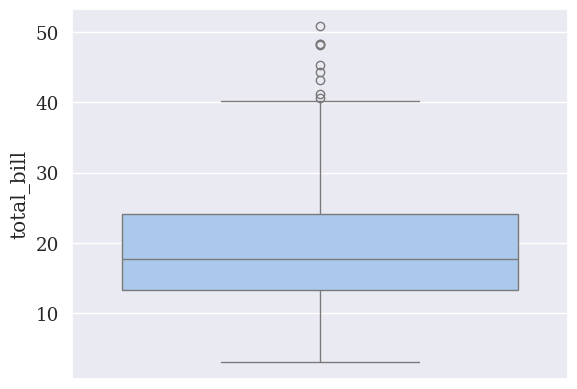

In [123]:
# themes : set_theme, set_style, axes_style. 
# styles: whitegrid, darkgrid, white, dark, ticks
sns.set_theme(style='darkgrid',palette='pastel',font='serif',font_scale=1.2)
sns.boxplot(data=tips,y='total_bill')